PRACTICA 1

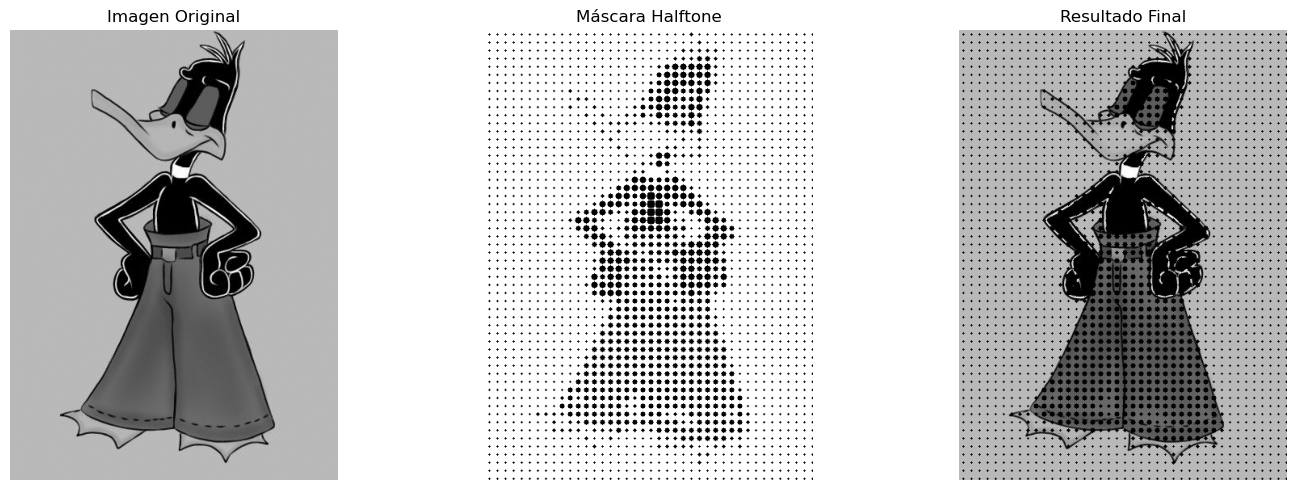

✅ Imagen guardada como: pato_halftone_result.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def halftone_mask_effect(image_path, dot_spacing=10, max_radius=5, save_output=False):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("⚠️ Error: No se pudo cargar la imagen. Verifica la ruta.")
        return
    
    h, w = img.shape
    mask = np.ones((h, w), dtype=np.uint8) * 255  
    for y in range(0, h, dot_spacing):
        for x in range(0, w, dot_spacing):
            block = img[y:y+dot_spacing, x:x+dot_spacing]
            if block.size == 0:
                continue
            intensity = np.mean(block)
            radius = int(max_radius * (1 - intensity / 255))

            if radius > 0:
                center_x = x + dot_spacing // 2
                center_y = y + dot_spacing // 2
                cv2.circle(mask, (center_x, center_y), radius, (0,), -1)

    result = cv2.bitwise_and(img, mask)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Imagen Original")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("Máscara Halftone")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("Resultado Final")
    plt.imshow(result, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    if save_output:
        output_path = os.path.splitext(image_path)[0] + "_halftone_result.jpg"
        cv2.imwrite(output_path, result)
        print(f"✅ Imagen guardada como: {output_path}")
halftone_mask_effect('pato.jpg', dot_spacing=10, max_radius=5, save_output=True)


PRACTICA 2

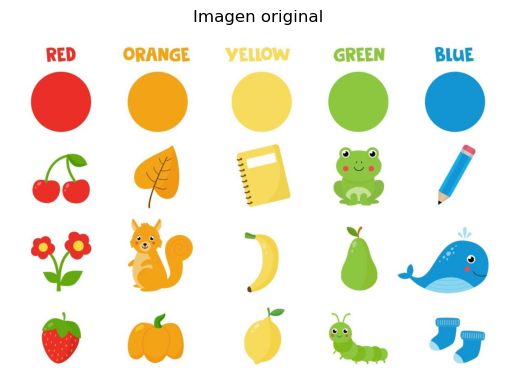

RED: 6 objetos
ORANGE: 4 objetos
YELLOW: 5 objetos
GREEN: 5 objetos
BLUE: 6 objetos


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "colores.jpg"
img = Image.open(image_path).convert("RGB")
img_np = np.array(img)

plt.imshow(img_np)
plt.axis('off')
plt.title("Imagen original")
plt.show()


height, width, _ = img_np.shape
column_width = width // 5  
start_y = int(height * 0.25)  
colors = ["RED", "ORANGE", "YELLOW", "GREEN", "BLUE"]
conteo_colores = {}

for i, color in enumerate(colors):
    x_start = i * column_width
    x_end = (i + 1) * column_width if i < 4 else width
    column = img_np[start_y:, x_start:x_end]
    gray_column = np.mean(column, axis=2)
    binary_column = gray_column < 240  

    row_sum = np.sum(binary_column, axis=1)
    is_object = row_sum > 10

    count = 0
    in_object = False
    for val in is_object:
        if val and not in_object:
            count += 1
            in_object = True
        elif not val:
            in_object = False

    conteo_colores[color] = count

for color, count in conteo_colores.items():
    print(f"{color}: {count} objetos")


PRACTICA 3

El Canny Edge Detector es un algoritmo que:

Convierte la imagen a escala de grises.

Aplica un desenfoque (Gaussian Blur) para reducir el ruido.

Calcula el gradiente de la imagen para detectar cambios bruscos de intensidad (bordes).

Aplica umbrales para decidir qué bordes conservar.

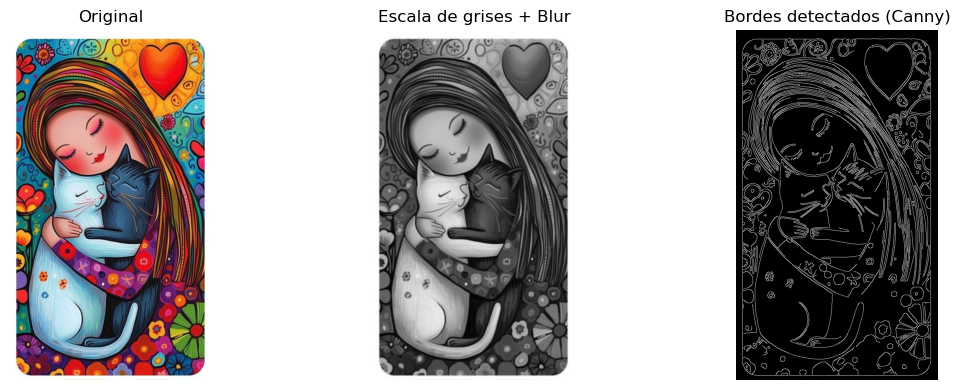

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, threshold1=100, threshold2=200)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Escala de grises + Blur")
plt.imshow(blurred, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Bordes detectados (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
